In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

###  1. 连接数据库并探索模式

In [3]:
# 连接数据库（请确保 chinook.db 文件在当前目录）
conn = sqlite3.connect('chinook.db')

In [4]:
# 查看数据库中所有的表
tables_query = "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;"
tables = pd.read_sql_query(tables_query, conn)
print("数据库中的表：")
print(tables)

数据库中的表：
             name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track


In [5]:
# 对于每个核心表，显示其结构和前几行，便于理解关系
core_tables = ['Artist', 'Album', 'Track', 'Genre', 'MediaType', 
               'Employee', 'Customer', 'Invoice', 'InvoiceLine', 
               'Playlist', 'PlaylistTrack']

for table in core_tables:
    if table in tables['name'].values:
        print(f"\n--- 表 {table} 的结构 ---")
        schema = pd.read_sql_query(f"PRAGMA table_info({table})", conn)
        print(schema[['name', 'type','pk']])
        
        print(f"\n--- 表 {table} 的前 3 行 ---")
        sample = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 3", conn)
        print(sample)
        print("-" * 60)


--- 表 Artist 的结构 ---
       name           type  pk
0  ArtistId        INTEGER   1
1      Name  NVARCHAR(120)   0

--- 表 Artist 的前 3 行 ---
   ArtistId       Name
0         1      AC/DC
1         2     Accept
2         3  Aerosmith
------------------------------------------------------------

--- 表 Album 的结构 ---
       name           type  pk
0   AlbumId        INTEGER   1
1     Title  NVARCHAR(160)   0
2  ArtistId        INTEGER   0

--- 表 Album 的前 3 行 ---
   AlbumId                                  Title  ArtistId
0        1  For Those About To Rock We Salute You         1
1        2                      Balls to the Wall         2
2        3                      Restless and Wild         2
------------------------------------------------------------

--- 表 Track 的结构 ---
           name           type  pk
0       TrackId        INTEGER   1
1          Name  NVARCHAR(200)   0
2       AlbumId        INTEGER   0
3   MediaTypeId        INTEGER   0
4       GenreId        INTEGER   0
5     

### 2.问题 1：销量排名前十的歌曲

In [6]:
query_top_tracks = """
SELECT 
    t.Name AS TrackName,
    COUNT(il.InvoiceLineId) AS PurchaseCount
FROM Track t
JOIN InvoiceLine il ON t.TrackId = il.TrackId
GROUP BY t.TrackId
ORDER BY PurchaseCount DESC
LIMIT 10;
"""
df_top_tracks = pd.read_sql_query(query_top_tracks, conn)
print("销量最高的 10 首歌曲：")
print(df_top_tracks)

销量最高的 10 首歌曲：
                   TrackName  PurchaseCount
0          Balls to the Wall              2
1           Inject The Venom              2
2                 Snowballed              2
3                   Overdose              2
4            Deuces Are Wild              2
5             Not The Doctor              2
6          Por Causa De Você              2
7  Welcome Home (Sanitarium)              2
8                  Snowblind              2
9                 Cornucopia              2


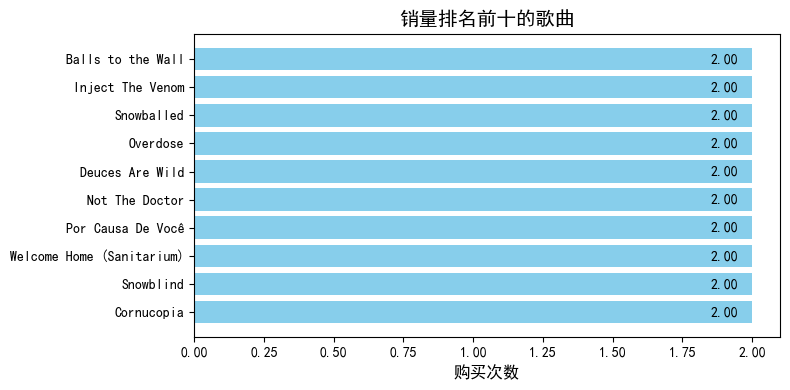

In [27]:
# 可视化销量前十歌曲（柱状图）
plt.rcParams['font.family'] = 'SimHei' 
plt.figure(figsize=(8, 4))
plt.barh(df_top_tracks['TrackName'], df_top_tracks['PurchaseCount'], color='skyblue')
plt.xlabel('购买次数', fontsize=12)
plt.title('销量排名前十的歌曲', fontsize=14)
plt.gca().invert_yaxis()  # 使销量最高的显示在最上面
for i, v in enumerate(df_top_tracks['PurchaseCount']):
    plt.text(1.9, i+0.15 , f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

In [8]:
query_top_country = """
SELECT 
    BillingCountry AS Country,
    SUM(Total) AS TotalRevenue
FROM Invoice 
GROUP BY BillingCountry
ORDER BY TotalRevenue DESC;
"""
df_country_revenue = pd.read_sql_query(query_top_country, conn)
print("各国总收入（从高到低）：")
print(df_country_revenue)
top_country = df_country_revenue.iloc[0]
print(f"\n收入最高的国家是：{top_country['Country']}，总收入 ${top_country['TotalRevenue']:.2f}")

各国总收入（从高到低）：
           Country  TotalRevenue
0              USA        523.06
1           Canada        303.96
2           France        195.10
3           Brazil        190.10
4          Germany        156.48
5   United Kingdom        112.86
6   Czech Republic         90.24
7         Portugal         77.24
8            India         75.26
9            Chile         46.62
10         Ireland         45.62
11         Hungary         45.62
12         Austria         42.62
13         Finland         41.62
14     Netherlands         40.62
15          Norway         39.62
16          Sweden         38.62
17           Spain         37.62
18          Poland         37.62
19           Italy         37.62
20         Denmark         37.62
21         Belgium         37.62
22       Australia         37.62
23       Argentina         37.62

收入最高的国家是：USA，总收入 $523.06


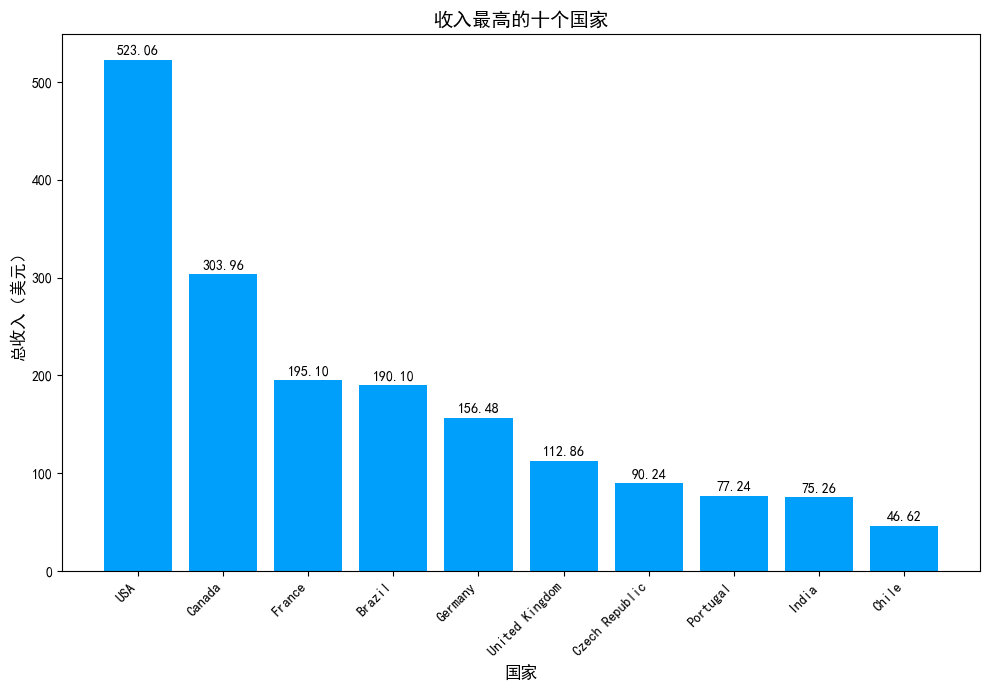

In [33]:
# 可视化前十国家收入（柱状图）
top10_countries = df_country_revenue.head(10)
plt.figure(figsize=(10, 7))
plt.bar(top10_countries['Country'], top10_countries['TotalRevenue'], color='#009ffc')
plt.xlabel('国家', fontsize=12)
plt.ylabel('总收入（美元）', fontsize=12)
plt.title('收入最高的十个国家', fontsize=14)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(top10_countries['TotalRevenue']):
    plt.text(i,v+5, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

In [34]:
query_top_employee = """
SELECT 
    e.EmployeeId,
    e.FirstName || ' ' || e.LastName AS EmployeeName,
    SUM(i.Total) AS TotalSales
FROM Employee e
JOIN Customer c ON e.EmployeeId = c.SupportRepId
JOIN Invoice i ON c.CustomerId = i.CustomerId
WHERE e.Title LIKE '%Sales%Agent%'   -- 只考虑销售代理
GROUP BY e.EmployeeId
ORDER BY TotalSales DESC;
"""

df_employee_sales = pd.read_sql_query(query_top_employee, conn)
print("销售员工业绩排名：")
print(df_employee_sales)

top_employee = df_employee_sales.iloc[0]
print(f"\n业绩最好的销售员工是：{top_employee['EmployeeName']}，总销售额 ${top_employee['TotalSales']:.2f}")

销售员工业绩排名：
   EmployeeId   EmployeeName  TotalSales
0           3   Jane Peacock      833.04
1           4  Margaret Park      775.40
2           5  Steve Johnson      720.16

业绩最好的销售员工是：Jane Peacock，总销售额 $833.04


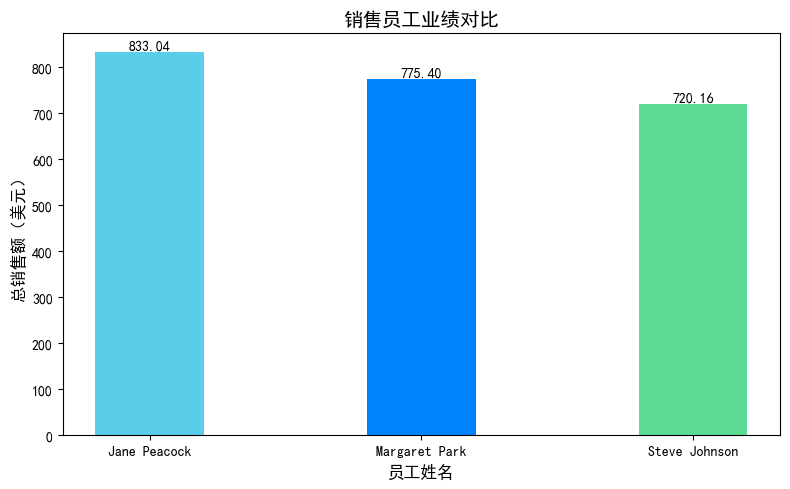

In [40]:
# 可视化各员工销售额（柱状图）
plt.figure(figsize=(8, 5))
plt.bar(df_employee_sales['EmployeeName'], df_employee_sales['TotalSales'],  color=['#59cde9','#0083fe','#5cdb95'],width=0.4)
plt.xlabel('员工姓名', fontsize=12)
plt.ylabel('总销售额（美元）', fontsize=12)
plt.title('销售员工业绩对比', fontsize=14)
for i, v in enumerate(df_employee_sales['TotalSales']):
    plt.text(i,v+5, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

In [41]:
conn.close()